In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier

print("Entorno de ThakaTravel IA preparado correctamente")

Entorno de ThakaTravel IA preparado correctamente


In [2]:
np.random.seed(42)

n = 1000

datos = pd.DataFrame({
    "edad": np.random.randint(18, 65, n),
    "presupuesto": np.random.randint(50, 1000, n),
    "duracion_viaje": np.random.randint(1, 15, n),
    "preferencia_naturaleza": np.random.randint(1, 11, n),
    "preferencia_cultura": np.random.randint(1, 11, n),
    "preferencia_aventura": np.random.randint(1, 11, n),
    "preferencia_gastronomia": np.random.randint(1, 11, n),
    "destinos_visitados": np.random.randint(0, 15, n)
})

def recomendar(row):
    preferencias = {
        "Naturaleza": row["preferencia_naturaleza"],
        "Cultura": row["preferencia_cultura"],
        "Aventura": row["preferencia_aventura"],
        "Gastronomia": row["preferencia_gastronomia"]
    }
    return max(preferencias, key=preferencias.get)

datos["categoria_recomendada"] = datos.apply(recomendar, axis=1)

print("Dataset creado:", datos.shape)
datos.head()

Dataset creado: (1000, 9)


,edad,presupuesto,duracion_viaje,preferencia_naturaleza,preferencia_cultura,preferencia_aventura,preferencia_gastronomia,destinos_visitados,categoria_recomendada
0,56,62,9,4,9,2,3,1,Cultura
1,46,217,12,9,2,1,1,5,Naturaleza
2,32,691,6,9,4,4,4,7,Naturaleza
3,60,645,6,9,4,7,3,12,Naturaleza
4,25,370,5,10,2,10,1,2,Naturaleza


In [3]:
np.random.seed(42)

n = 1000

datos = pd.DataFrame({
    "edad": np.random.randint(18, 65, n),
    "presupuesto": np.random.randint(50, 1000, n),
    "duracion_viaje": np.random.randint(1, 15, n),
    "preferencia_naturaleza": np.random.randint(1, 11, n),
    "preferencia_cultura": np.random.randint(1, 11, n),
    "preferencia_aventura": np.random.randint(1, 11, n),
    "preferencia_gastronomia": np.random.randint(1, 11, n),
    "destinos_visitados": np.random.randint(0, 15, n)
})

def recomendar(row):
    preferencias = {
        "Naturaleza": row["preferencia_naturaleza"],
        "Cultura": row["preferencia_cultura"],
        "Aventura": row["preferencia_aventura"],
        "Gastronomia": row["preferencia_gastronomia"]
    }
    return max(preferencias, key=preferencias.get)

datos["categoria_recomendada"] = datos.apply(recomendar, axis=1)

print("Dataset creado:", datos.shape)
datos.head()

Dataset creado: (1000, 9)


,edad,presupuesto,duracion_viaje,preferencia_naturaleza,preferencia_cultura,preferencia_aventura,preferencia_gastronomia,destinos_visitados,categoria_recomendada
0,56,62,9,4,9,2,3,1,Cultura
1,46,217,12,9,2,1,1,5,Naturaleza
2,32,691,6,9,4,4,4,7,Naturaleza
3,60,645,6,9,4,7,3,12,Naturaleza
4,25,370,5,10,2,10,1,2,Naturaleza


In [4]:
print("ESTADISTICAS DESCRIPTIVAS")
display(datos.describe())

print("\nVALORES NULOS")
print(datos.isnull().sum())

print("\nDISTRIBUCION DE CATEGORIAS")
print(datos["categoria_recomendada"].value_counts())

ESTADISTICAS DESCRIPTIVAS


,edad,presupuesto,duracion_viaje,preferencia_naturaleza,preferencia_cultura,preferencia_aventura,preferencia_gastronomia,destinos_visitados
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,40.986000,520.12900,7.369000,5.435000,5.513000,5.60600,5.501000,6.948000
std,13.497852,278.58395,4.054785,2.827679,2.896933,2.82573,2.915562,4.240906
min,18.000000,50.00000,1.000000,1.000000,1.000000,1.00000,1.000000,0.000000
25%,29.000000,277.75000,4.000000,3.000000,3.000000,3.00000,3.000000,3.000000
50%,42.000000,517.00000,7.000000,5.000000,6.000000,6.00000,6.000000,7.000000
75%,52.000000,761.25000,11.000000,8.000000,8.000000,8.00000,8.000000,11.000000
max,64.000000,999.00000,14.000000,10.000000,10.000000,10.00000,10.000000,14.000000



VALORES NULOS
edad                       0
presupuesto                0
duracion_viaje             0
preferencia_naturaleza     0
preferencia_cultura        0
preferencia_aventura       0
preferencia_gastronomia    0
destinos_visitados         0
categoria_recomendada      0
dtype: int64

DISTRIBUCION DE CATEGORIAS
categoria_recomendada
Naturaleza     301
Cultura        258
Aventura       247
Gastronomia    194
Name: count, dtype: int64


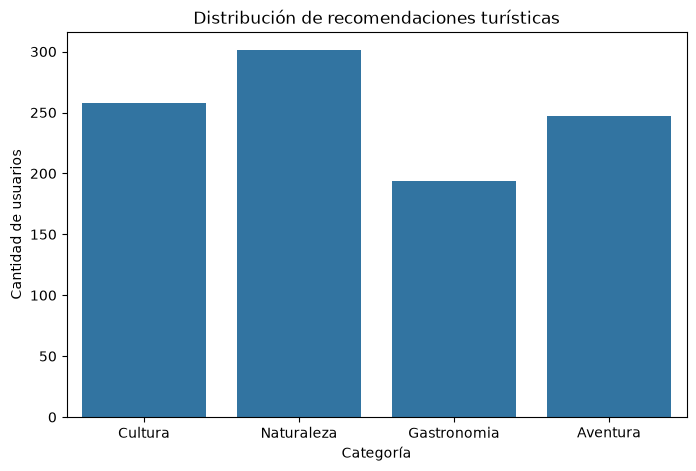

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=datos, x="categoria_recomendada")
plt.title("Distribución de recomendaciones turísticas")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de usuarios")
plt.show()

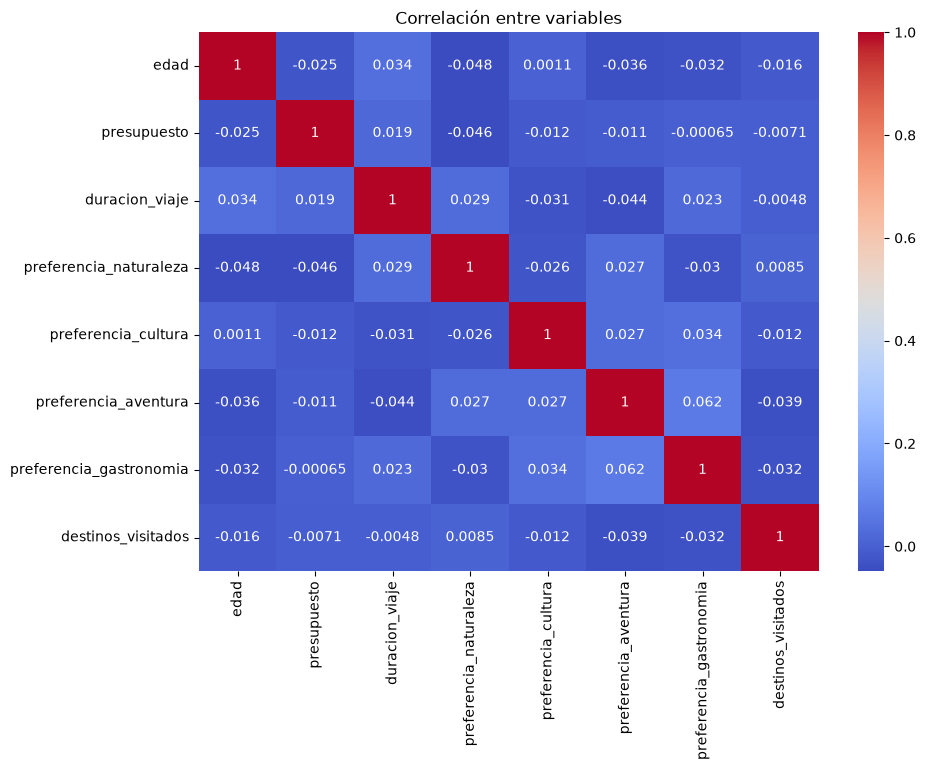

In [6]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    datos.drop(columns=["categoria_recomendada"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlación entre variables")
plt.show()

In [7]:
X = datos.drop(columns=["categoria_recomendada"])
y = datos["categoria_recomendada"]

categorias = {
    "Naturaleza": 0,
    "Cultura": 1,
    "Aventura": 2,
    "Gastronomia": 3
}

y = y.map(categorias)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (800, 8)
Datos de prueba: (200, 8)


In [8]:
modelos = {
    "Regresion Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.1,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=42
    )
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    
    predicciones = modelo.predict(X_test)
    probabilidades = modelo.predict_proba(X_test)
    
    accuracy = accuracy_score(y_test, predicciones)
    f1 = f1_score(y_test, predicciones, average="weighted")
    auc = roc_auc_score(
        y_test,
        probabilidades,
        multi_class="ovr"
    )
    
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "F1": f1,
        "AUC-ROC": auc
    })

resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,Accuracy,F1,AUC-ROC
0,Regresion Logistica,1.000,1.000000,1.000000
1,Random Forest,0.925,0.924950,0.993971
2,XGBoost,0.985,0.985012,0.999586


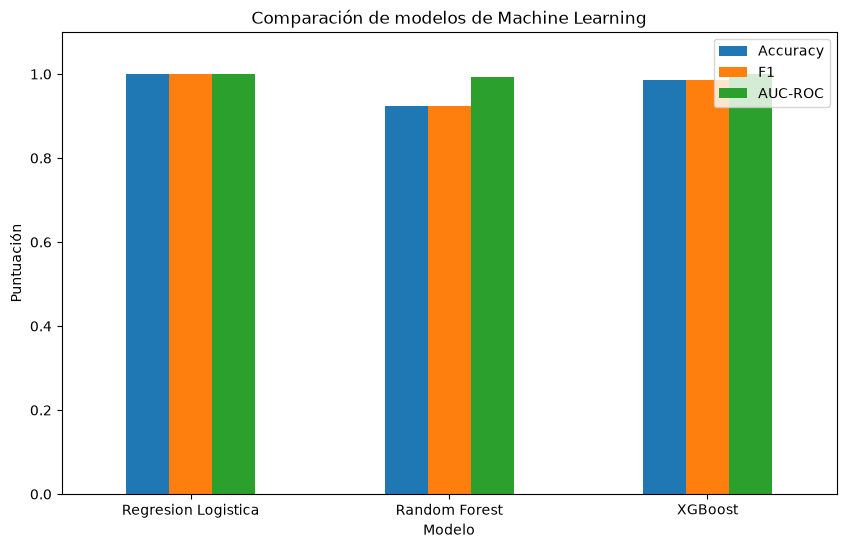

In [9]:
resultados_df.set_index("Modelo")[["Accuracy", "F1", "AUC-ROC"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparación de modelos de Machine Learning")
plt.ylabel("Puntuación")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.show()

In [13]:
mejor_modelo = resultados_df.loc[
    resultados_df["AUC-ROC"].idxmax()
]

print("MODELO SELECCIONADO")
print("-------------------")
print("Modelo:", mejor_modelo["Modelo"])
print("Accuracy:", round(mejor_modelo["Accuracy"], 4))
print("F1:", round(mejor_modelo["F1"], 4))
print("AUC-ROC:", round(mejor_modelo["AUC-ROC"], 4))

MODELO SELECCIONADO
-------------------
Modelo: Regresion Logistica
Accuracy: 1.0
F1: 1.0
AUC-ROC: 1.0
